# Part 2: Transformer Scaling Study 

1. Runs LR sweep on the Tiny model
2. Trains 5 model sizes (Tiny → XL) with best LR
3. Creates scaling plots with power law fits
4. Tracks training metrics (loss, throughput, memory)

## 2.1 Setup

In [1]:
from google.colab import drive
drive.mount("/content/drive")

import os, sys, yaml, json
BASE_DIR = "/content/drive/MyDrive/svg-scaling"
PROJECT_DIR = "/content/drive/MyDrive/svg-scaling-laws"
sys.path.insert(0, PROJECT_DIR)

!pip install -q datasets tokenizers lxml cairosvg mup wandb scipy seaborn tqdm pyyaml

Mounted at /content/drive
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.6/75.6 kB 5.5 MB/s eta 0:00:00


In [2]:

# Load configs
with open(os.path.join(PROJECT_DIR, "configs", "model_configs.yaml")) as f:
    model_configs = yaml.safe_load(f)
with open(os.path.join(PROJECT_DIR, "configs", "training_config.yaml")) as f:
    train_config = yaml.safe_load(f)

# Verify data exists
for split in ["train.bin", "val.bin", "test.bin"]:
    path = os.path.join(train_config["data_dir"], split)
    if os.path.exists(path):
        size_mb = os.path.getsize(path) / 1e6
        print(f"{split}: {size_mb:.1f} MB")
    else:
        print(f" {split}: NOT FOUND — dataprocesing required")

train.bin: 246.6 MB
val.bin: 2.6 MB
test.bin: 2.5 MB


## 2.2 Verify Model Architectures

In [3]:
import torch
from model.transformer import GPT
from model.utils import print_model_summary

print("Model Architecture Summary:")
print(f"{'Name':<10} {'Params':>12} {'n_layer':>8} {'n_head':>8} {'n_embd':>8} {'d_ff':>8}")
print("-" * 60)
for name, cfg in model_configs.items():
    model = GPT.from_config_dict(cfg, vocab_size=train_config["vocab_size"])
    params = model.count_parameters(non_embedding=True)
    print(f"{name:<10} {params:>12,} {cfg['n_layer']:>8} {cfg['n_head']:>8} {cfg['n_embd']:>8} {cfg['d_ff']:>8}")
    del model
torch.cuda.empty_cache()

Model Architecture Summary:
Name             Params  n_layer   n_head   n_embd     d_ff
------------------------------------------------------------
tiny          1,311,872        4        4      128      512
small         3,443,136        6        6      192      768
medium       12,194,688        6        6      384     1536
large        33,565,184       10        8      512     2048
xl           88,099,584       12       12      768     3072


## 2.3 Learning Rate Sweep (Tiny Model)

In [4]:
%%javascript
function KeepAlive() { console.log("ping"); }
setInterval(KeepAlive, 60000);

<IPython.core.display.Javascript object>

In [6]:
from training.lr_sweep import lr_sweep

best_lr, sweep_results = lr_sweep(
    model_config=model_configs["tiny"],
    train_config=train_config,
    model_name="tiny",
    use_wandb=False,
)
print(f"\nBest learning rate: {best_lr}")


Learning Rate Sweep: tiny
Testing 7 learning rates: [3e-05, 0.0001, 0.0003, 0.001, 0.003, 0.01, 0.03]

--- LR = 3.0e-05 ---

Loading data...
  Micro batch size: 64, Gradient accumulation: 1
  Loaded /content/drive/MyDrive/svg-scaling/data/train.bin: 123,306,698 tokens, ~1,881 batches
  Loaded /content/drive/MyDrive/svg-scaling/data/val.bin: 1,299,907 tokens, ~19 batches
  Tokens per step: 65,536
  Max iterations (1 epoch): 1,881

Initializing model: tiny_lr3e-05

Model: tiny_lr3e-05
Total parameters:            1,967,232
Trainable parameters:        1,967,232
Non-embedding parameters:    1,311,872


/content/drive/MyDrive/svg-scaling-laws/training/train.py:184: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()



Training tiny_lr3e-05 (SP) | LR=3.0e-05 | 1881 iters


/content/drive/MyDrive/svg-scaling-laws/training/train.py:235: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(dtype=torch.float16):


  iter      0/1881 | loss 8.3516 | lr 1.50e-07 | 2165 tok/s | 30s elapsed


/content/drive/MyDrive/svg-scaling-laws/training/train.py:95: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(dtype=torch.float16):


  >>> val_loss: 8.3526
  iter     50/1881 | loss 7.9928 | lr 7.65e-06 | 455652 tok/s | 84s elapsed
  iter    100/1881 | loss 7.5477 | lr 1.52e-05 | 444228 tok/s | 91s elapsed
  iter    150/1881 | loss 7.1795 | lr 2.27e-05 | 462778 tok/s | 99s elapsed
  iter    200/1881 | loss 6.8574 | lr 3.00e-05 | 460214 tok/s | 107s elapsed
  >>> val_loss: 6.8272
  iter    250/1881 | loss 6.5371 | lr 2.99e-05 | 437468 tok/s | 117s elapsed
  iter    300/1881 | loss 6.2688 | lr 2.98e-05 | 446035 tok/s | 125s elapsed
  iter    350/1881 | loss 6.0053 | lr 2.95e-05 | 442361 tok/s | 132s elapsed
  iter    400/1881 | loss 5.7208 | lr 2.91e-05 | 437235 tok/s | 140s elapsed
  >>> val_loss: 5.7185
  iter    450/1881 | loss 5.4841 | lr 2.86e-05 | 430050 tok/s | 150s elapsed
  iter    500/1881 | loss 5.2696 | lr 2.79e-05 | 424415 tok/s | 158s elapsed
  iter    550/1881 | loss 5.0028 | lr 2.72e-05 | 428906 tok/s | 167s elapsed
  iter    600/1881 | loss 4.8345 | lr 2.64e-05 | 430415 tok/s | 175s elapsed
  >>> val_

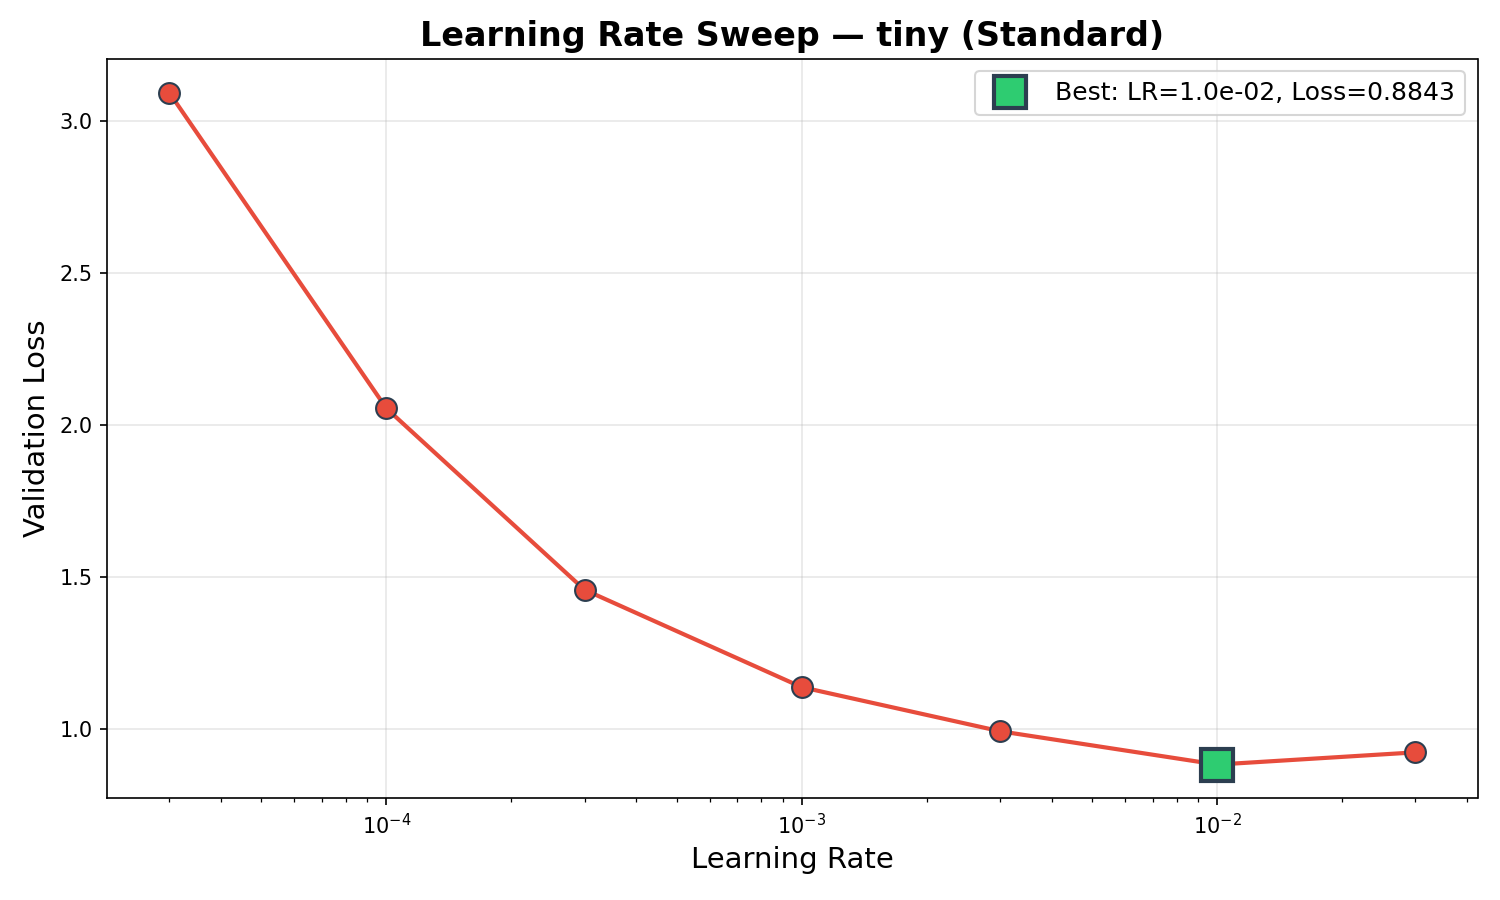

In [7]:
# Display LR sweep plot
from IPython.display import Image, display
plot_path = os.path.join(train_config["results_dir"], "sp_lr_sweep_tiny.png")
if os.path.exists(plot_path):
    display(Image(plot_path, width=600))

## 2.4 Training All Models (1 Epoch Each)

In [8]:
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)
# Update training config with best LR from sweep/ the lr good for all models
train_config["learning_rate"] = 0.001
print(f"Using LR: {train_config['learning_rate']}")

# Train models sequentially (smallest to largest)
from training.train import train_model

all_results = {}
for name in ["tiny", "small", "medium"]:
    print(f"\n{'#' * 60}")
    print(f"# Training: {name.upper()}")
    print(f"{'#' * 60}")

    results = train_model(
        model_name=name,
        model_config=model_configs[name],
        train_config=train_config,
        use_wandb=False,
    )
    all_results[name] = results
    print(f"\n {name}: val_loss = {results['final_val_loss']:.4f}")

Using LR: 0.001

############################################################
# Training: TINY
############################################################

Loading data...
  Micro batch size: 64, Gradient accumulation: 1
  Loaded /content/drive/MyDrive/svg-scaling/data/train.bin: 123,306,698 tokens, ~1,881 batches
  Loaded /content/drive/MyDrive/svg-scaling/data/val.bin: 1,299,907 tokens, ~19 batches
  Tokens per step: 65,536
  Max iterations (1 epoch): 1,881

Initializing model: tiny

Model: tiny
Total parameters:            1,967,232
Trainable parameters:        1,967,232
Non-embedding parameters:    1,311,872

Training tiny (SP) | LR=1.0e-03 | 1881 iters
  iter      0/1881 | loss 8.3113 | lr 5.00e-06 | 1096984 tok/s | 0s elapsed
  >>> val_loss: 8.3020
  iter     50/1881 | loss 6.3439 | lr 2.55e-04 | 2010267 tok/s | 4s elapsed
  iter    100/1881 | loss 3.7590 | lr 5.05e-04 | 1977098 tok/s | 5s elapsed
  iter    150/1881 | loss 2.5943 | lr 7.55e-04 | 2060925 tok/s | 7s elapsed
  iter

In [11]:
from training.train import train_model
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)
train_config["learning_rate"] = 0.001
all_results={}
for name in ["large"]:
    results = train_model(
        model_name=name,
        model_config=model_configs[name],
        train_config=train_config,
        use_wandb=False,
    )
    all_results[name] = results
    print(f"\n {name}: val_loss = {results['final_val_loss']:.4f}")


Loading data...
  Micro batch size: 64, Gradient accumulation: 1
  Loaded /content/drive/MyDrive/svg-scaling/data/train.bin: 123,306,698 tokens, ~1,881 batches
  Loaded /content/drive/MyDrive/svg-scaling/data/val.bin: 1,299,907 tokens, ~19 batches
  Tokens per step: 65,536
  Max iterations (1 epoch): 1,881

Initializing model: large

Model: large
Total parameters:           36,186,624
Trainable parameters:       36,186,624
Non-embedding parameters:   33,565,184

Training large (SP) | LR=1.0e-03 | 1881 iters
  iter      0/1881 | loss 8.3011 | lr 5.00e-06 | 356815 tok/s | 0s elapsed
  >>> val_loss: 7.9306
  iter     50/1881 | loss 2.6329 | lr 2.55e-04 | 428590 tok/s | 12s elapsed
  iter    100/1881 | loss 2.3899 | lr 5.05e-04 | 422324 tok/s | 28s elapsed
  iter    150/1881 | loss 2.1192 | lr 7.55e-04 | 431892 tok/s | 36s elapsed
  iter    200/1881 | loss 1.9411 | lr 1.00e-03 | 435441 tok/s | 43s elapsed
  >>> val_loss: 1.8766
  iter    250/1881 | loss 1.6030 | lr 9.98e-04 | 433115 tok/s

In [12]:
for name in ["xl"]:
    results = train_model(
        model_name=name,
        model_config=model_configs[name],
        train_config=train_config,
        use_wandb=False,
    )
    all_results[name] = results
    print(f"\n {name}: val_loss = {results['final_val_loss']:.4f}")


Loading data...
  Micro batch size: 64, Gradient accumulation: 1
  Loaded /content/drive/MyDrive/svg-scaling/data/train.bin: 123,306,698 tokens, ~1,881 batches
  Loaded /content/drive/MyDrive/svg-scaling/data/val.bin: 1,299,907 tokens, ~19 batches
  Tokens per step: 65,536
  Max iterations (1 epoch): 1,881

Initializing model: xl

Model: xl
Total parameters:           92,031,744
Trainable parameters:       92,031,744
Non-embedding parameters:   88,099,584

Training xl (SP) | LR=1.0e-03 | 1881 iters
  iter      0/1881 | loss 8.6447 | lr 5.00e-06 | 201300 tok/s | 0s elapsed
  >>> val_loss: 7.8471
  iter     50/1881 | loss 2.5062 | lr 2.55e-04 | 225425 tok/s | 45s elapsed
  iter    100/1881 | loss 2.3516 | lr 5.05e-04 | 225838 tok/s | 59s elapsed
  iter    150/1881 | loss 2.1272 | lr 7.55e-04 | 224936 tok/s | 74s elapsed
  iter    200/1881 | loss 1.8225 | lr 1.00e-03 | 226060 tok/s | 88s elapsed
  >>> val_loss: 1.7802
  iter    250/1881 | loss 1.5935 | lr 9.98e-04 | 226173 tok/s | 132s e

## 2.5 Scaling Analysis & Power Law Fit

In [5]:
import json
import os

# results directory
RESULTS_DIR = "/content/drive/MyDrive/svg-scaling/results"
os.makedirs(RESULTS_DIR, exist_ok=True)

# finalized results
summary = {
  "tiny": {
    "params": 1311872,
    "final_val_loss": 1.1600,
    "total_time_s": 70,
    "tokens_per_sec": 1751104,
    "gpu_memory_gb": 26.63
  },
  "small": {
    "params": 3443136,
    "final_val_loss": 0.9988,
    "total_time_s": 112,
    "tokens_per_sec": 1096438,
    "gpu_memory_gb": 26.63
  },
  "medium": {
    "params": 12194688,
    "final_val_loss": 0.8560,
    "total_time_s": 201,
    "tokens_per_sec": 614248,
    "gpu_memory_gb": 26.63
  },
  "large": {
    "params": 33565184,
    "final_val_loss": 0.7663,
    "total_time_s": 365,
    "tokens_per_sec": 337995,
    "gpu_memory_gb": 26.63
  },
  "xl": {
    "params": 88099584,
    "final_val_loss": 0.6799,
    "total_time_s": 744,
    "tokens_per_sec": 165726,
    "gpu_memory_gb": 28.65
  }
}

# Saving the summary file
summary_path = os.path.join(RESULTS_DIR, "sp_scaling_summary.json")
with open(summary_path, 'w') as f:
    json.dump(summary, f, indent=2)

print(f"summary created at: {summary_path}")
print("rerun the Scaling Analysis cell to get α and R² values!")


summary created at: /content/drive/MyDrive/svg-scaling/results/sp_scaling_summary.json
rerun the Scaling Analysis cell to get α and R² values!


In [6]:
from analysis.scaling_plots import run_scaling_analysis

RESULTS_DIR = train_config["results_dir"]
ANALYSIS_DIR = os.path.join(BASE_DIR, "results", "analysis")

popt, r2 = run_scaling_analysis(RESULTS_DIR, ANALYSIS_DIR)
if popt is not None:
    print(f"\nScaling exponent α = {popt[1]:.4f}")
    print(f"R² = {r2:.4f}")


Fitting power law: L = a * N^(-α) + c
  a = 17.4311
  α = 0.2206
  c = 0.3775
  R² = 0.9988
Saved scaling plot: /content/drive/MyDrive/svg-scaling/results/analysis/sp_scaling_curve.png
Saved training curves: /content/drive/MyDrive/svg-scaling/results/analysis/sp_training_curves.png

Model        Params   Val Loss   Time (s)      Tok/s   GPU (GB)
--------------------------------------------------------------------
tiny      1,311,872     1.1600         70    1751104      26.63
small     3,443,136     0.9988        112    1096438      26.63
medium   12,194,688     0.8560        201     614248      26.63
large    33,565,184     0.7663        365     337995      26.63
xl       88,099,584     0.6799        744     165726      28.65

Scaling exponent α = 0.2206
R² = 0.9988



sp_scaling_curve.png:


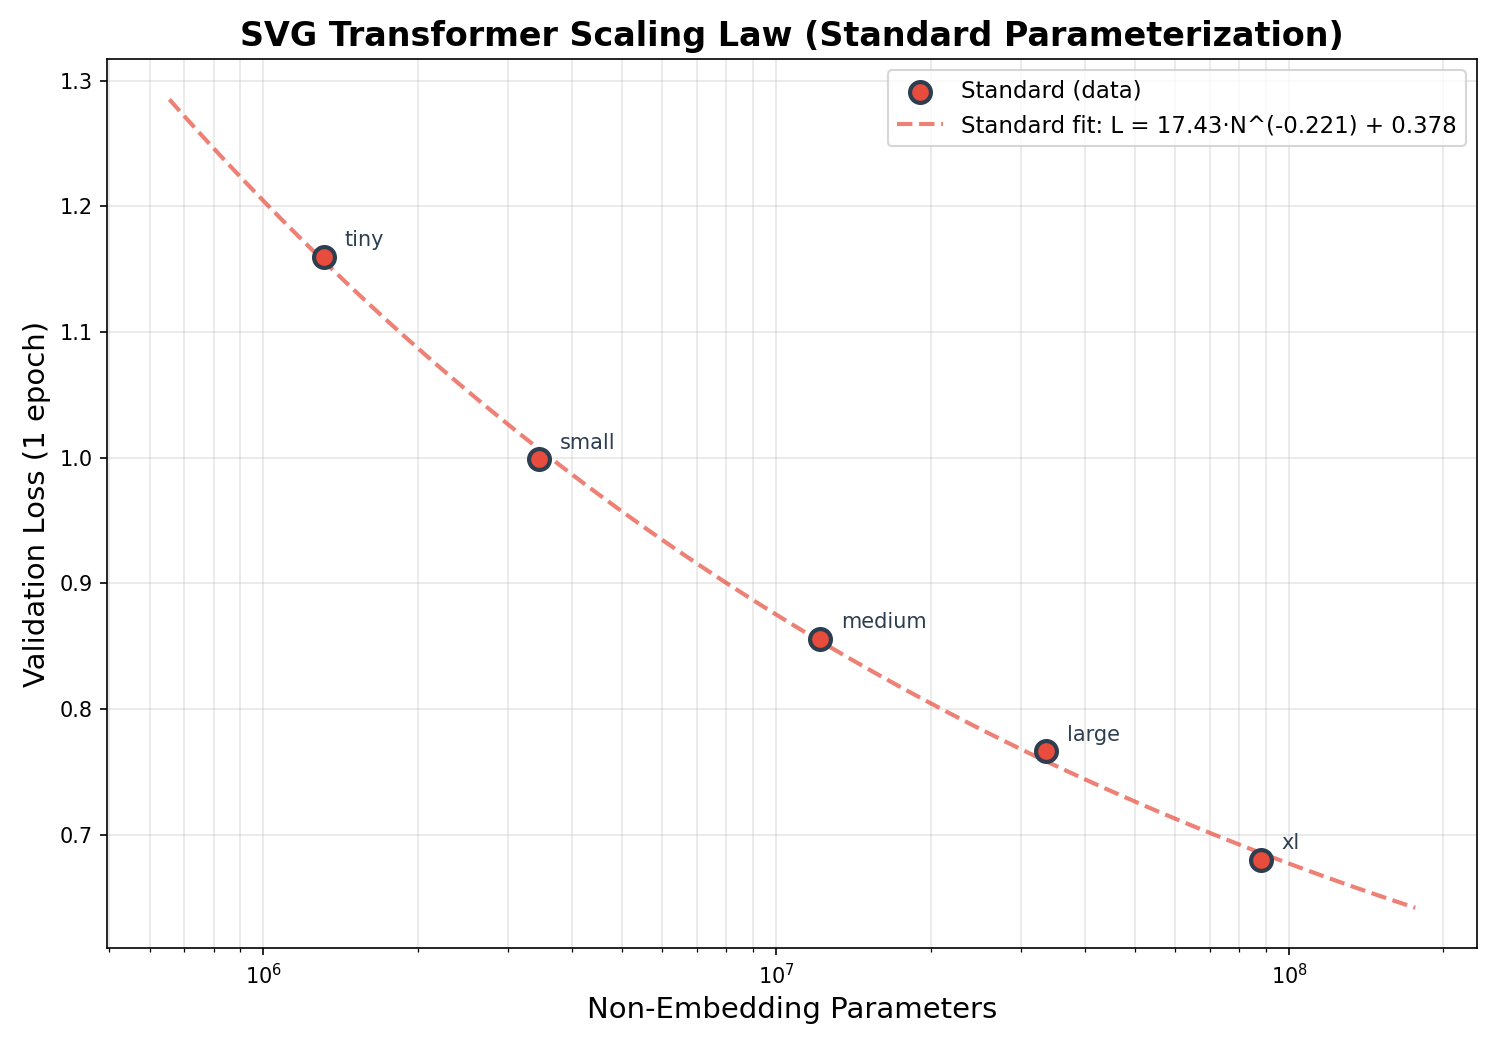


sp_training_curves.png:


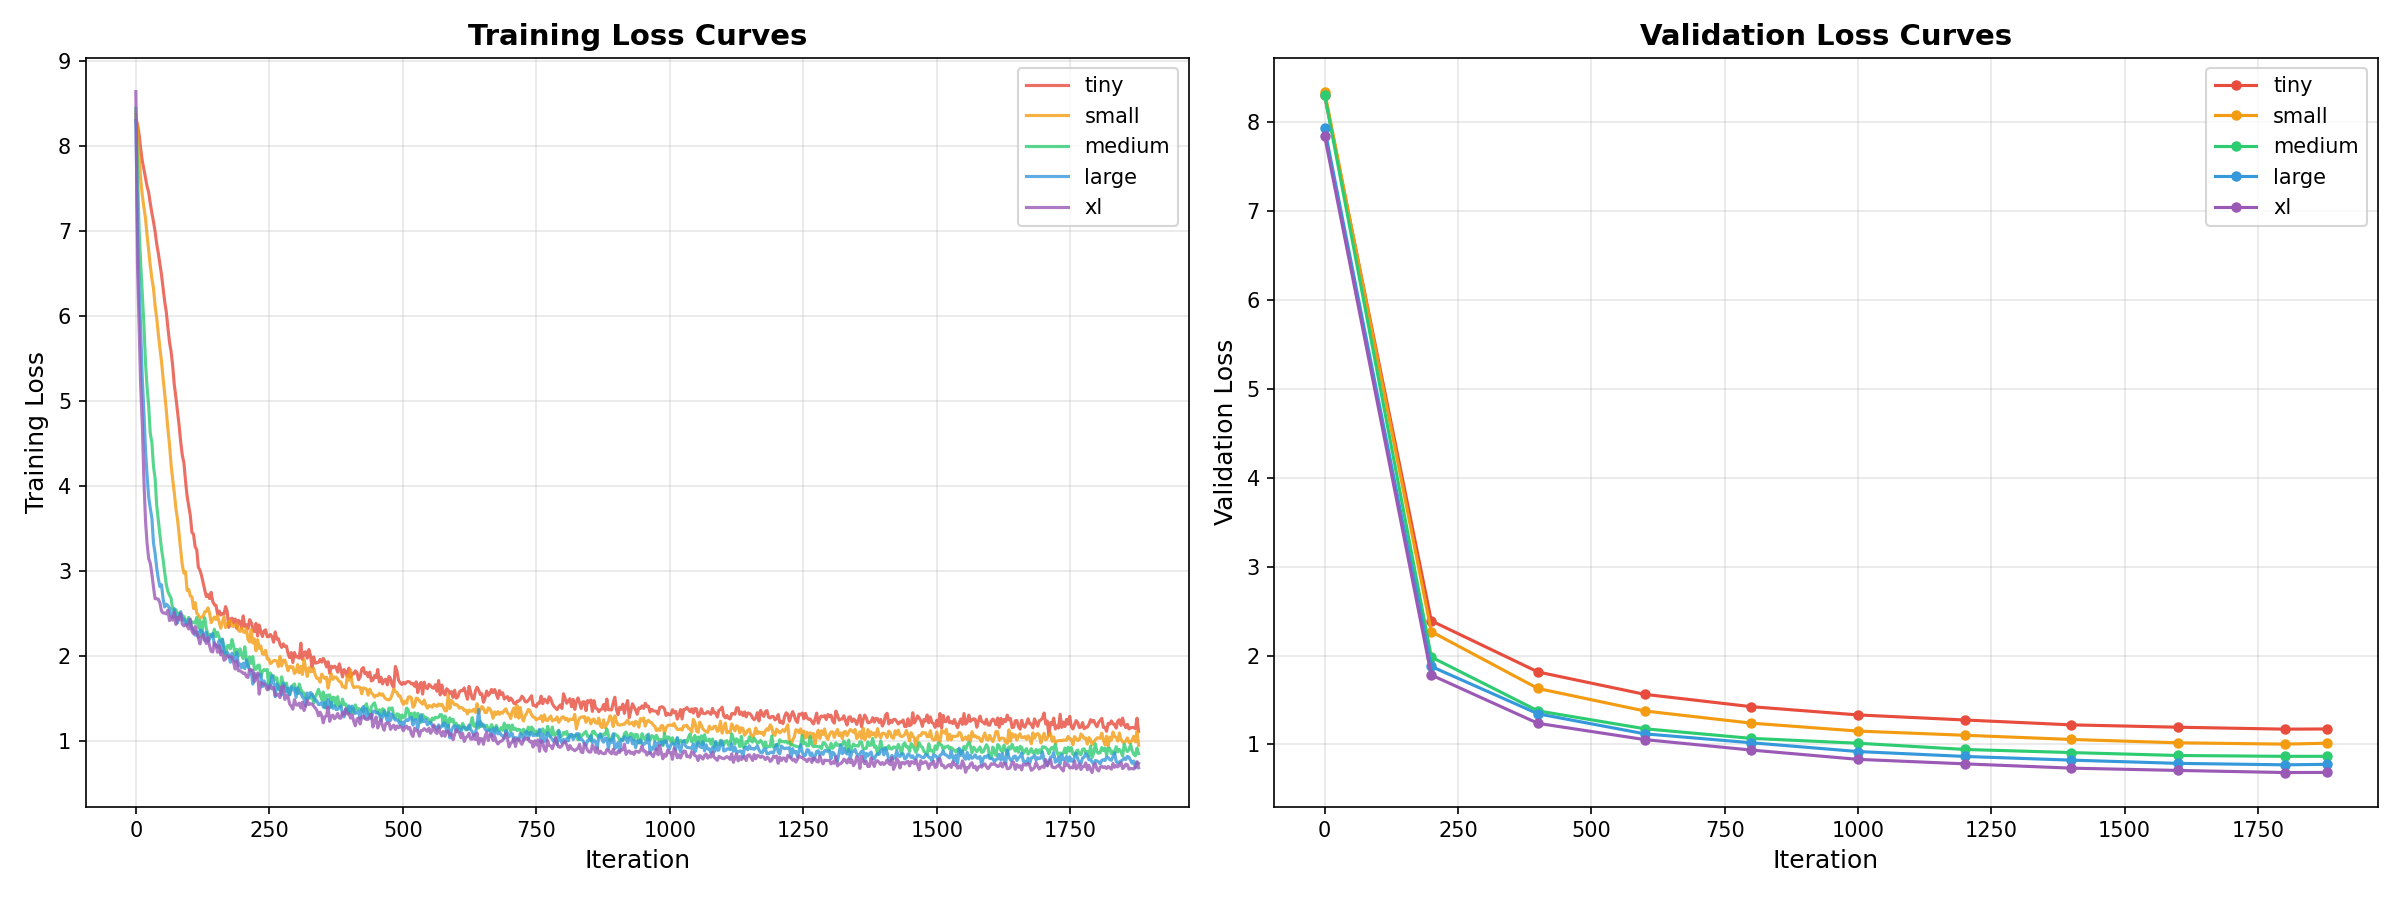

In [7]:
# scaling plots
from IPython.display import Image, display
for img in ["sp_scaling_curve.png", "sp_training_curves.png"]:
    path = os.path.join(ANALYSIS_DIR, img)
    if os.path.exists(path):
        print(f"\n{img}:")
        display(Image(path, width=700))